In [7]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, zscore

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sys.path.append(str(Path('../autoimmune_analysis').resolve().parent))
from autoimmune_analysis.expression_module import (
    prepare_count_matrix,
    parse_gmt,
    calculate_signature_scores,
    plot_signatures_heatmap,
    run_deseq2,
    plot_volcano,
    plot_boxplot_stats,
    calculate_ifn_score
)

# Data loading
Loading pre-cleaned counts dataframe and metadata, mapping ENSEMBL gene names to symbols and converting to log2TPMs.

In [8]:
metadata = pd.read_csv('../data/metadata_with_predictions.csv', sep = ',')
log2_tpm, filtered_counts = prepare_count_matrix('../data/counts_merged.csv',
                                                 mapping_file='../data/genes_ensembl_length.csv')

Loaded counts: 59268 genes, 435 samples
Filtered counts matrix: 17347 genes, 435 samples
Log2 TPM table prepared


In [9]:
log2_tpm.head(5)

,SRR10342368,SRR10342369,SRR10342370,SRR10342371,SRR12794681,SRR12794682,SRR12794683,SRR12794684,SRR12794685,SRR12794686,...,SRR8181373,SRR8181374,SRR8181375,SRR8181376,SRR8181377,SRR8181378,SRR8181379,SRR8181380,SRR8181381,SRR8181382
Geneid,,,,,,,,,,,,,,,,,,,,,
A1BG,0.098889,0.269037,0.322680,0.000000,1.045063,1.393670,1.787311,1.769818,0.385773,1.779022,...,1.471168,0.813881,1.392029,1.272322,2.174990,1.942836,1.419033,2.155532,0.532075,0.811890
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.020381,0.000000,0.000000,0.000000,0.018495,0.019084,0.004761,0.000000
A2M,0.068448,0.037486,0.134996,0.121574,0.448002,0.213157,0.324067,0.232141,0.227224,0.342177,...,0.507392,0.332888,0.503034,0.788305,0.560334,0.327207,0.745379,0.907314,0.397466,0.248713
A2ML1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032009,...,0.000000,0.012782,0.027258,0.000000,0.037308,0.023893,0.024741,0.075261,0.000000,0.012741
A4GALT,0.000000,0.000000,0.210736,0.000000,0.000000,0.060116,0.147551,0.071618,0.000000,0.131424,...,0.000000,0.105224,0.057334,0.000000,0.052586,0.098947,0.000000,0.105524,0.079307,0.079381


# Gene signatures
As part of exploratory data analysis and quality control of used data, we analyzed gene expression patterns for known immune signatures. The analyzed signatures also include those associated with extracellular matrix and angiogenesis. These signatures are expected to be low and are used to confirm that the data used is indeed blood and has not been confounded with tissue.  

These signatures were calculated for all GSE datasets used in the project. In heatmaps, diagnoses are color-coded: green - healthy, red - SLE, blue - MS, purple - CLE.

In [10]:
signatures = parse_gmt('../data/gene_signatures.gmt')
print(f"Signatures loaded: {len(signatures)}")

Signatures loaded: 29


GSE139350
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


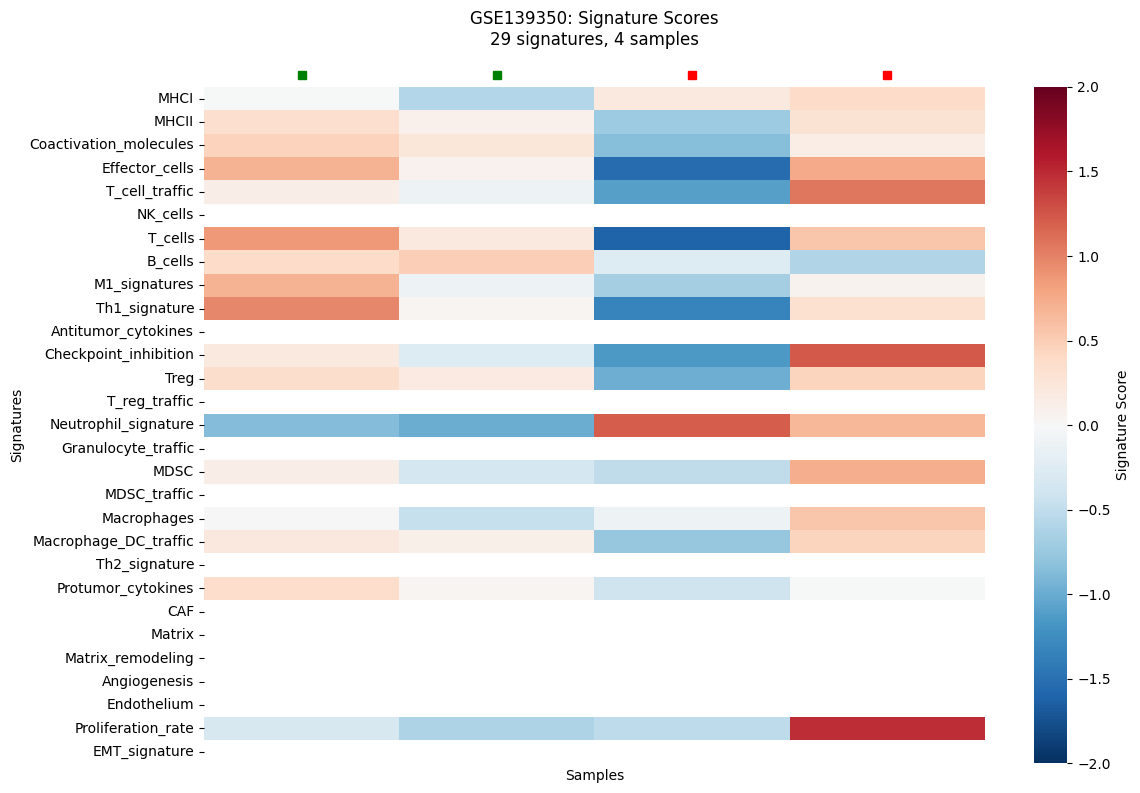

GSE159225
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


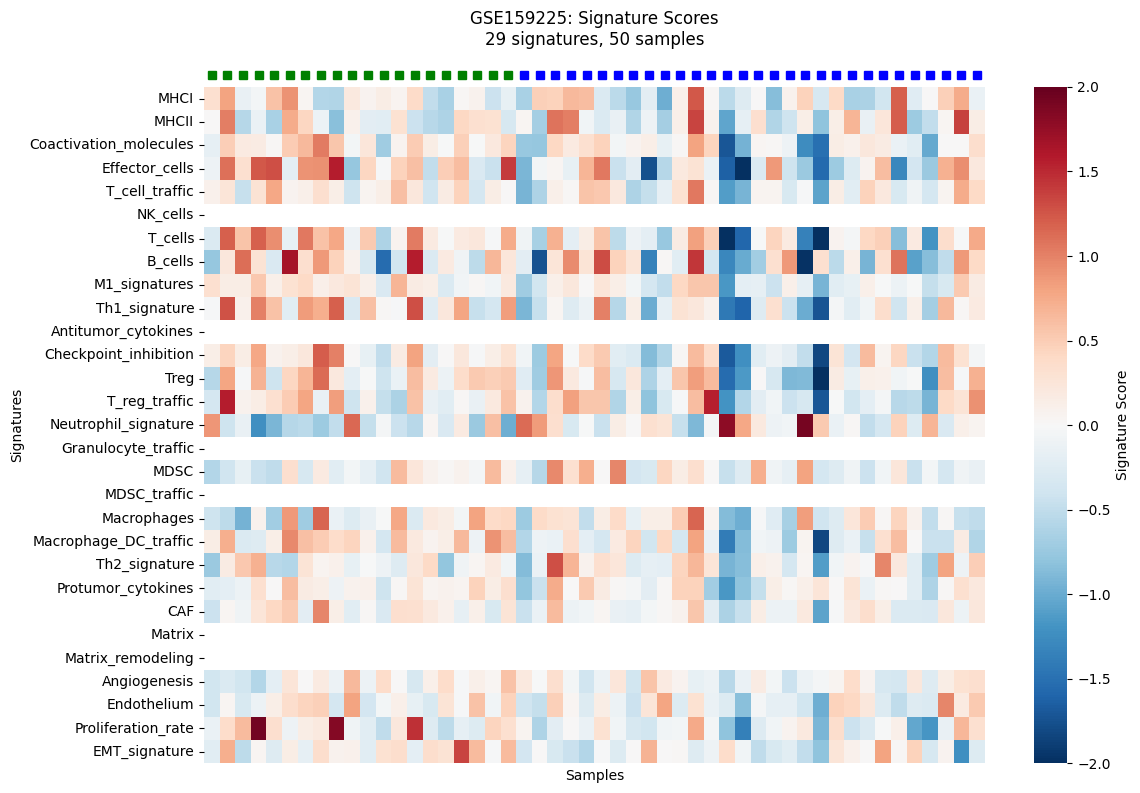

GSE162828
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


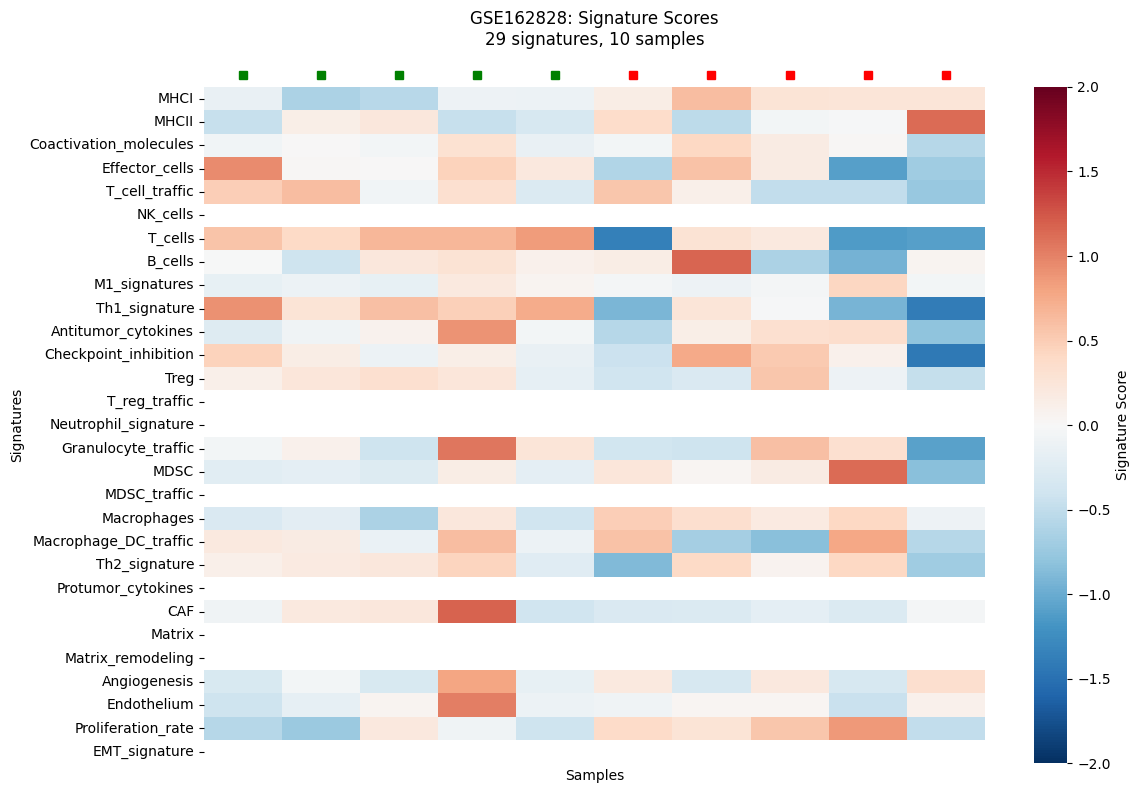

GSE165159
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


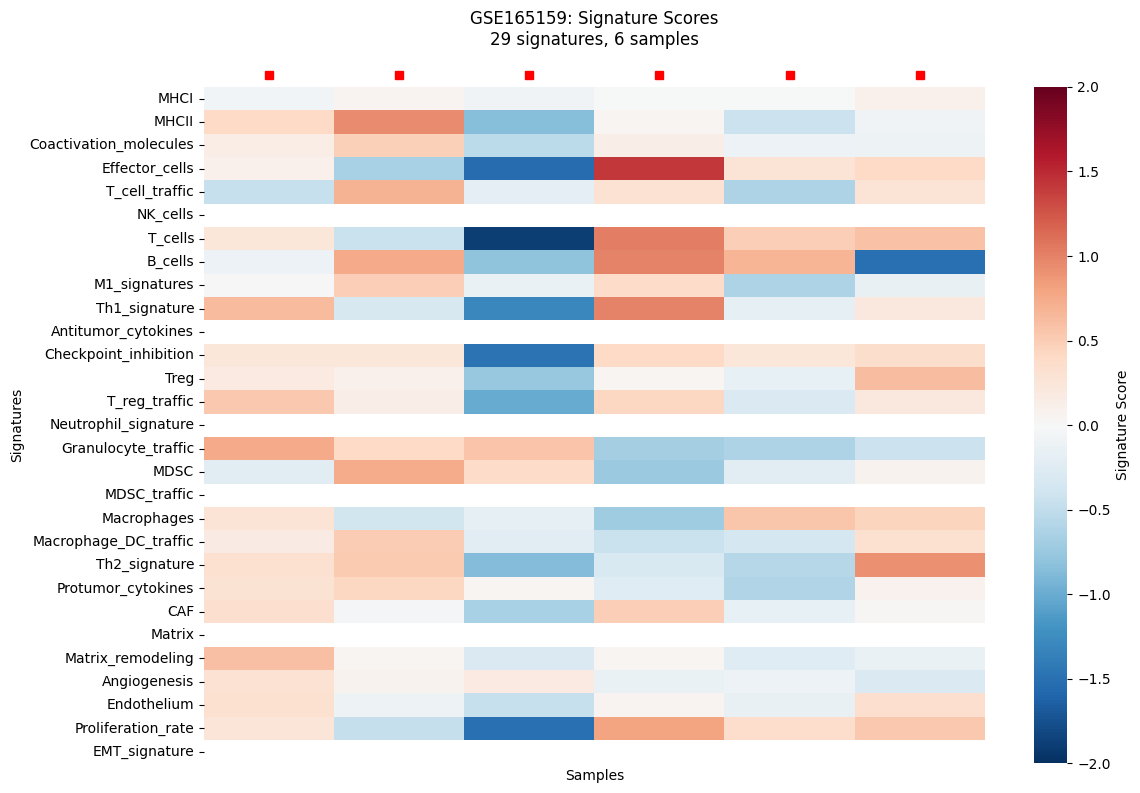

GSE167923
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


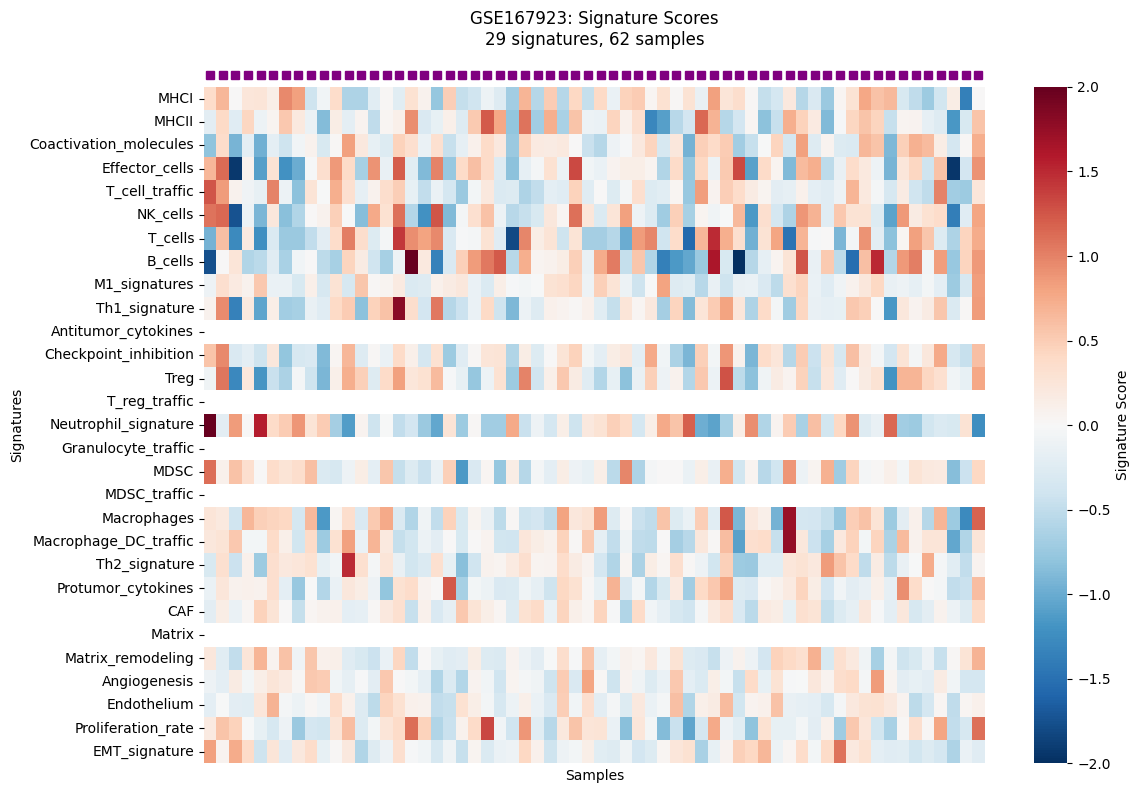

GSE169080
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


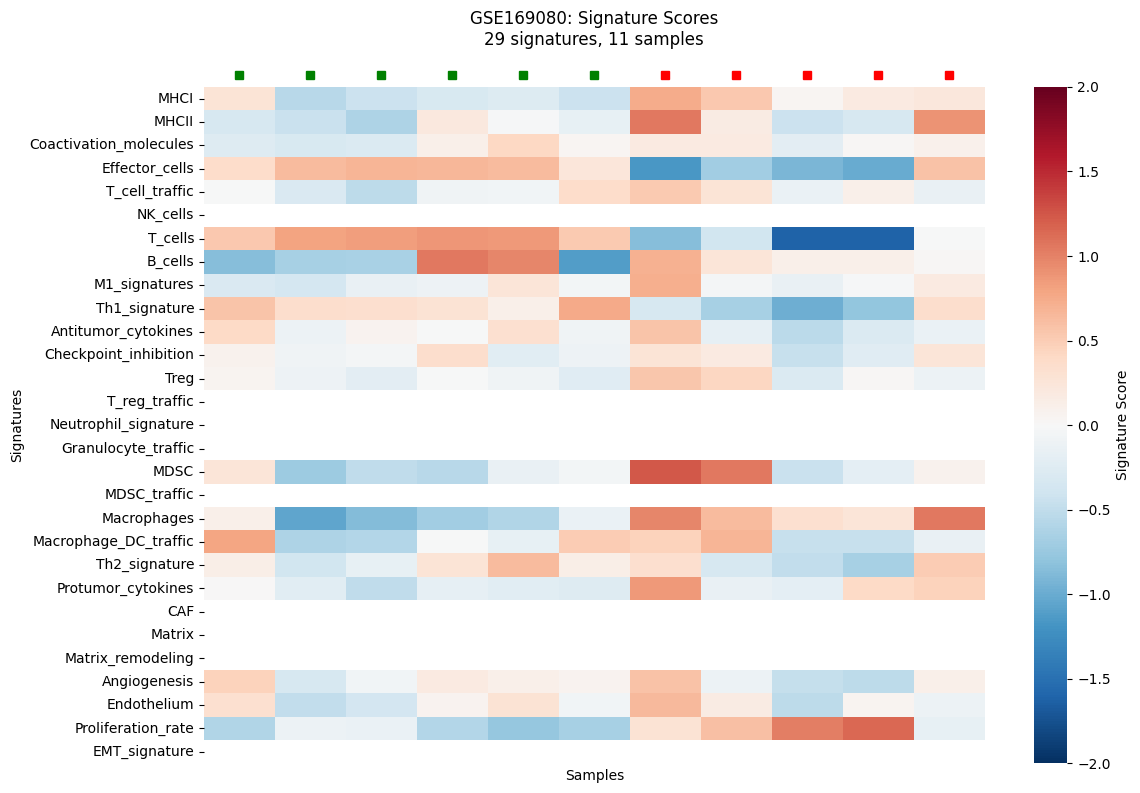

GSE175839
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


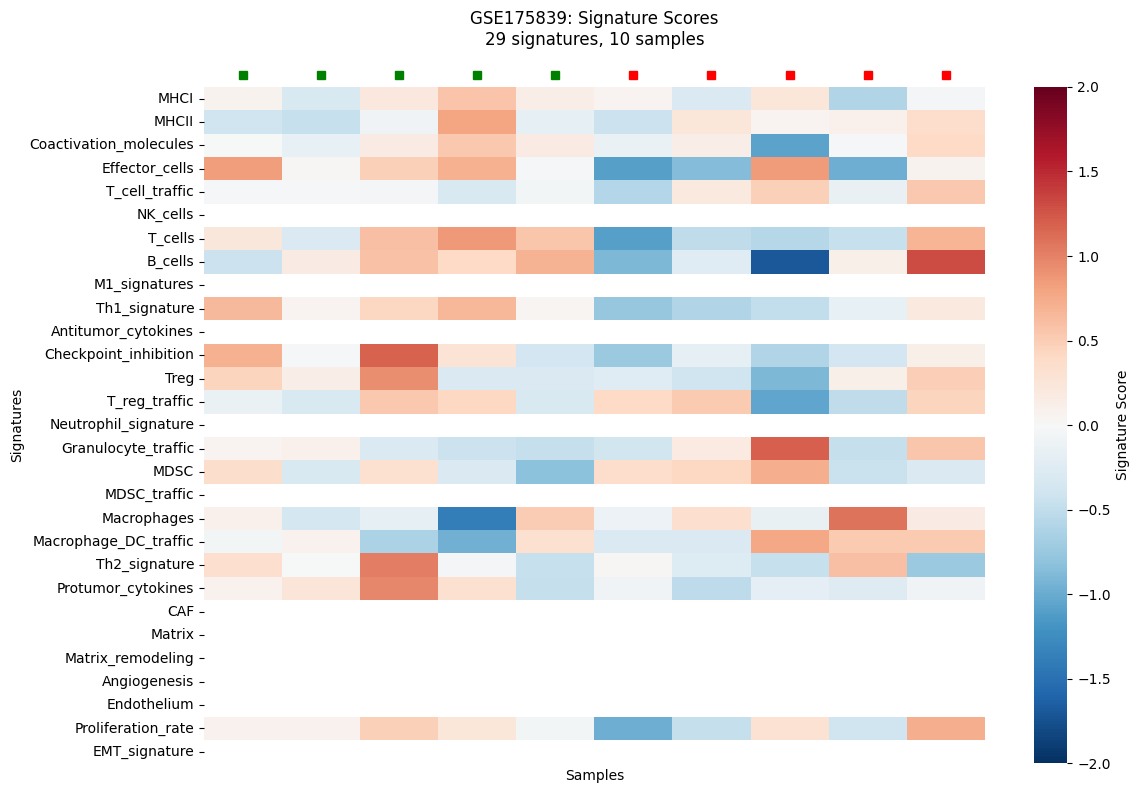

GSE235357
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


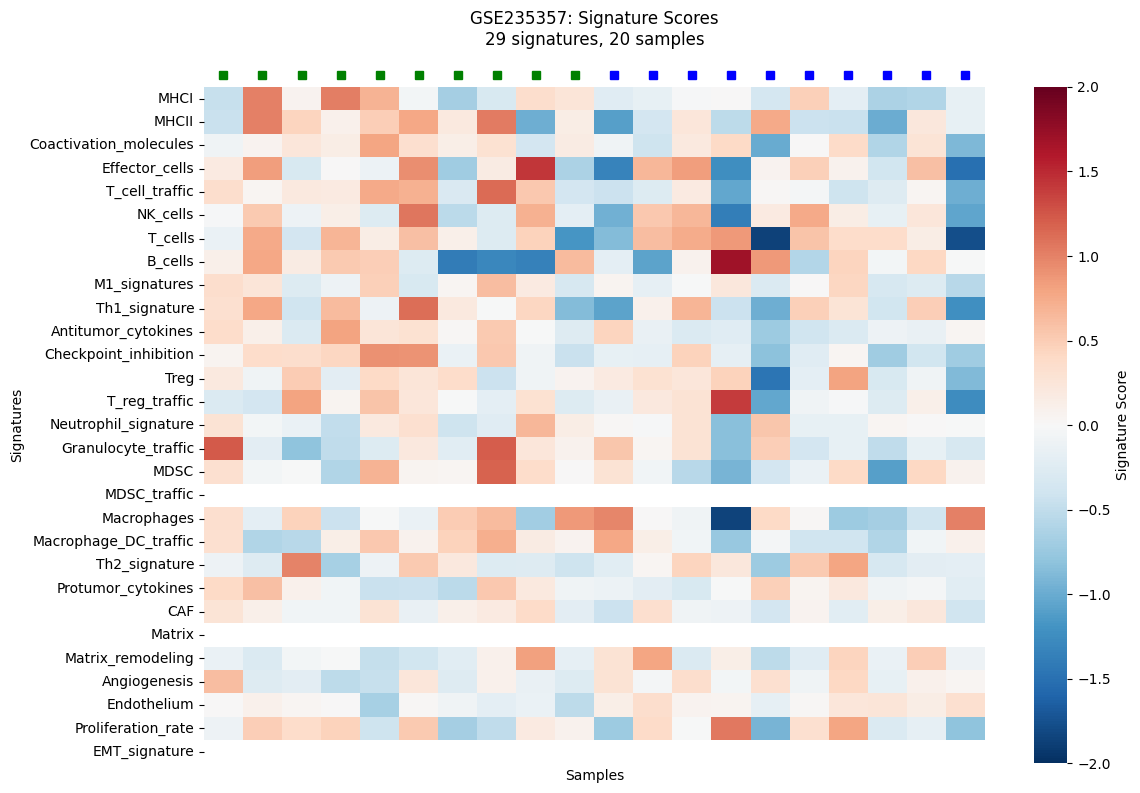

GSE250023
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


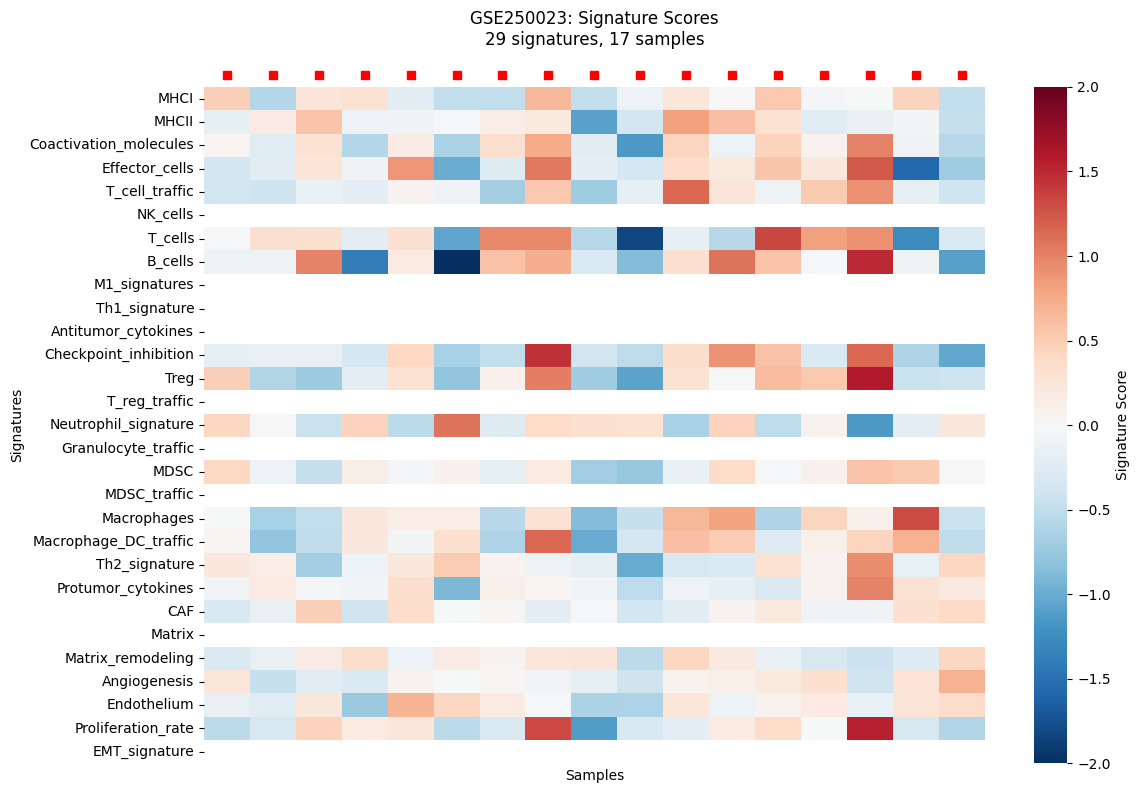

GSE250453
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


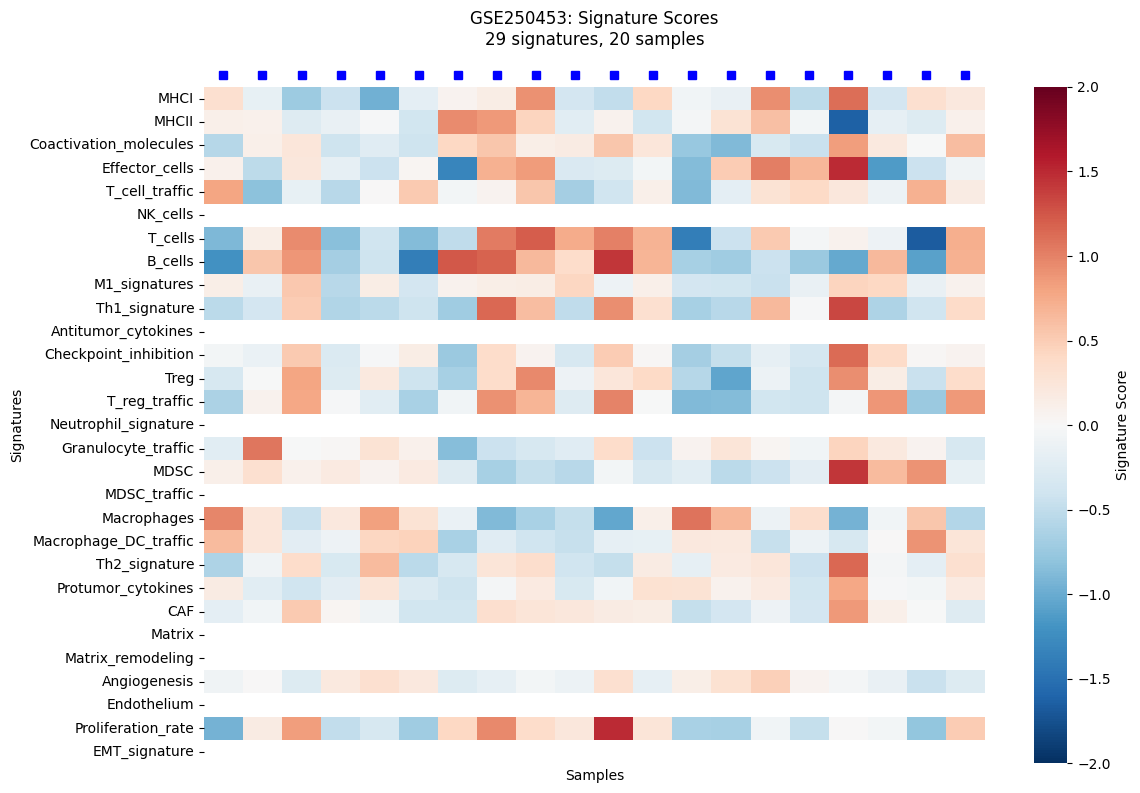

GSE80183
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


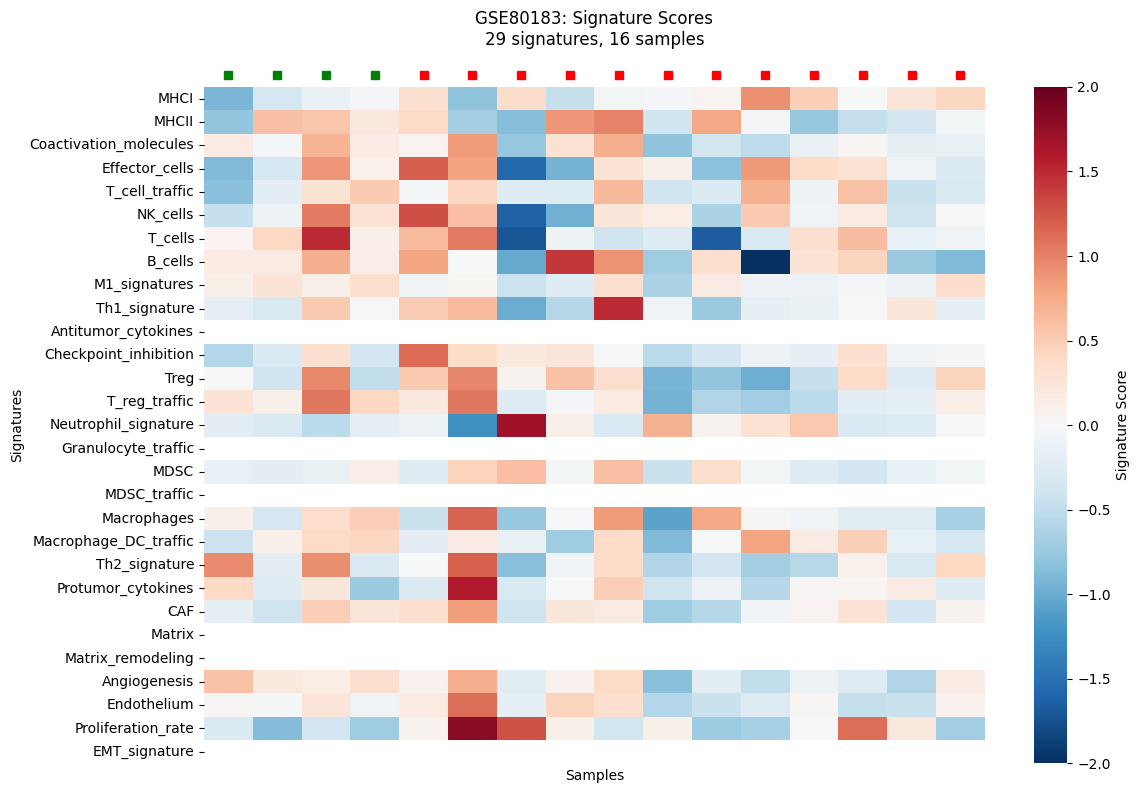

GSE86884
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes
Only 1 sample, cannot plot a heatmap
GSE92472
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 

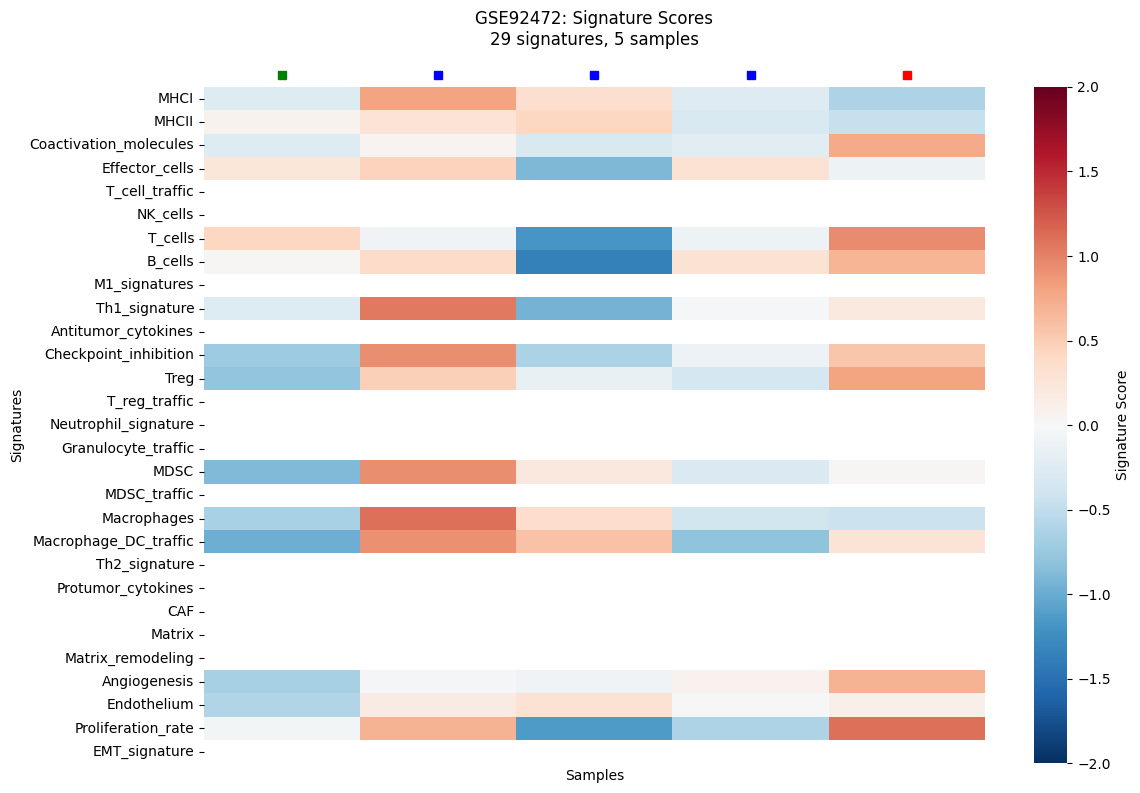

GSE116006
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


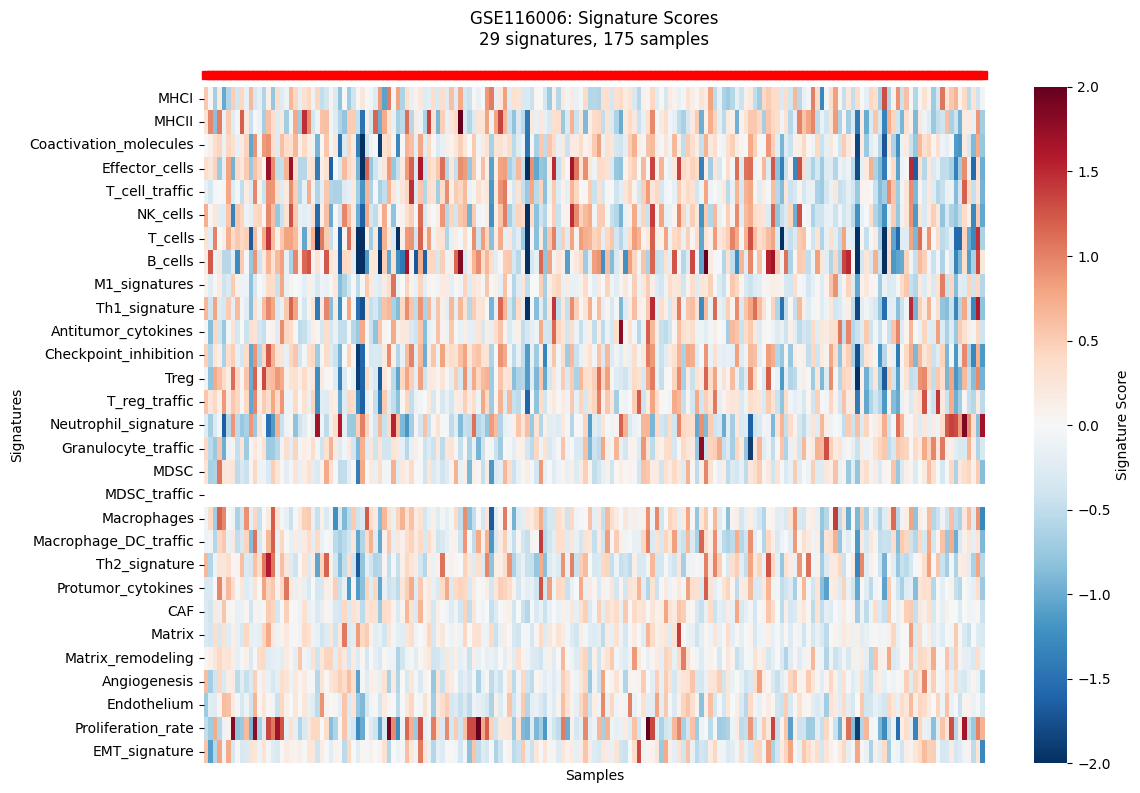

GSE122459
'MHCI': 7/8 genes
'MHCII': 9/9 genes
'Coactivation_molecules': 14/14 genes
'Effector_cells': 12/12 genes
'T_cell_traffic': 9/9 genes
'NK_cells': 17/17 genes
'T_cells': 10/11 genes
'B_cells': 13/13 genes
'M1_signatures': 9/9 genes
'Th1_signature': 7/7 genes
'Antitumor_cytokines': 6/6 genes
'Checkpoint_inhibition': 8/9 genes
'Treg': 7/7 genes
'T_reg_traffic': 7/7 genes
'Neutrophil_signature': 10/10 genes
'Granulocyte_traffic': 9/9 genes
'MDSC': 7/7 genes
'MDSC_traffic': 15/15 genes
'Macrophages': 8/8 genes
'Macrophage_DC_traffic': 8/8 genes
'Th2_signature': 5/5 genes
'Protumor_cytokines': 7/7 genes
'CAF': 19/19 genes
'Matrix': 15/15 genes
'Matrix_remodeling': 12/12 genes
'Angiogenesis': 15/15 genes
'Endothelium': 10/10 genes
'Proliferation_rate': 15/15 genes
'EMT_signature': 7/7 genes


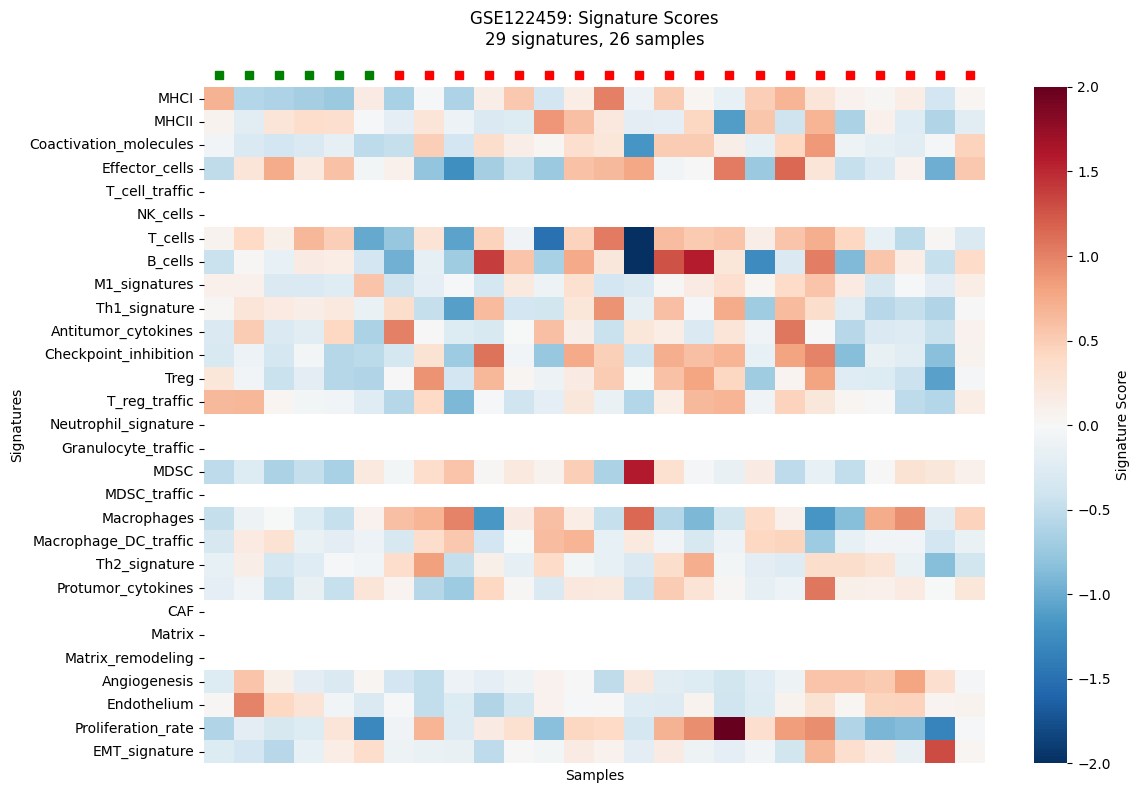

In [11]:
unique_gse = metadata['GSE'].unique()
for gse in unique_gse:
    print(gse)
    gse_metadata = metadata[metadata['GSE'] == gse].copy()
    gse_srr = gse_metadata['SRR'].tolist()
    gse_log2_tpm = log2_tpm[gse_srr]
    diagnoses_list = gse_metadata.set_index('SRR').loc[gse_srr, 'diagnosis'].tolist()
    scores_df = calculate_signature_scores(gse_log2_tpm, signatures)
    if len(gse_srr) > 1:
        plot_signatures_heatmap(scores_df, gse, diagnoses_list)
    else:
        print('Only 1 sample, cannot plot a heatmap')

# IFN score
We calculated the IFN score as an average of log2TPM values for 11 IFN-inducible genes, Z-scored across separate data sets. We showed that IFN-High and IFN-Low groups determined by our classifiers significantly differ (Mann-Whitney U test) by their IFN scores, supporting the biological validity of classification.

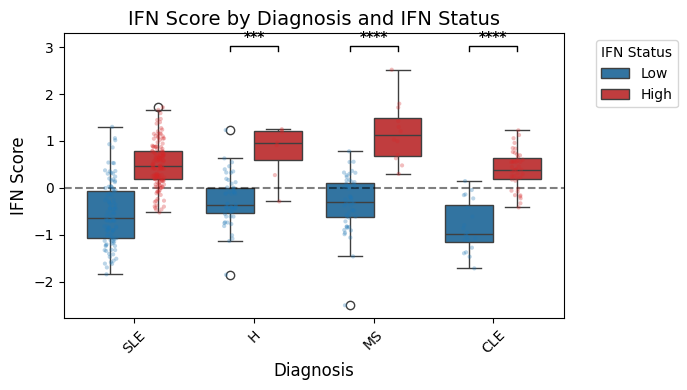

,SRR,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,disease_type,country,state_province,continent,ifn_status,Batch,IFN_Probability,Predicted_IFN_status,IFN_score
0,SRR10342368,GSE139350,PBMC,SLE,F,47.0,NaN,polyA,NaN,SLE,China,Hubei,NaN,NaN,1,0.06,Low,-0.082026
1,SRR10342369,GSE139350,PBMC,SLE,F,38.0,NaN,polyA,NaN,SLE,China,Hubei,NaN,NaN,1,0.25,Low,1.301327
2,SRR10342370,GSE139350,PBMC,H,F,45.0,NaN,polyA,NaN,H,China,Hubei,NaN,NaN,0,0.00,Low,-0.086708
3,SRR10342371,GSE139350,PBMC,H,F,37.0,NaN,polyA,NaN,H,China,Hubei,NaN,NaN,1,0.00,Low,-1.132593
4,SRR12794681,GSE159225,Leukocytes,MS,M,NaN,NaN,total,NaN,RR MS,Spain,NaN,Europe,NaN,2,0.00,Low,-0.467787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428,SRR8181378,GSE122459,PBMC,H,F,31.0,C,polyA,NaN,H,USA,CT,NaN,NaN,0,0.00,Low,-1.011562
429,SRR8181379,GSE122459,PBMC,H,F,34.0,H,polyA,NaN,H,USA,CT,NaN,NaN,0,0.01,Low,-0.518509
430,SRR8181380,GSE122459,PBMC,H,F,41.0,H,polyA,NaN,H,USA,CT,NaN,NaN,0,0.00,Low,-0.115399
431,SRR8181381,GSE122459,PBMC,H,F,22.0,C,polyA,NaN,H,USA,CT,NaN,NaN,0,0.00,Low,-1.851996


In [12]:
ifn_genes = ['IFI27', 'IFIT1', 'IFIT3', 'MX1', 'OAS1', 
             'RSAD2', 'STAT1', 'IFNAR1', 'IFNAR2']
metadata_with_predictions = pd.read_csv('../data/metadata_with_predictions.csv', sep=',')
calculate_ifn_score(metadata_with_predictions, log2_tpm, ifn_genes)

# Differential gene expression
We compared expression of IFN-inducible genes in all samples divided by IFN status and diagnosis. Mann-Whitney U test was used to compare gene expression (log2TPM).

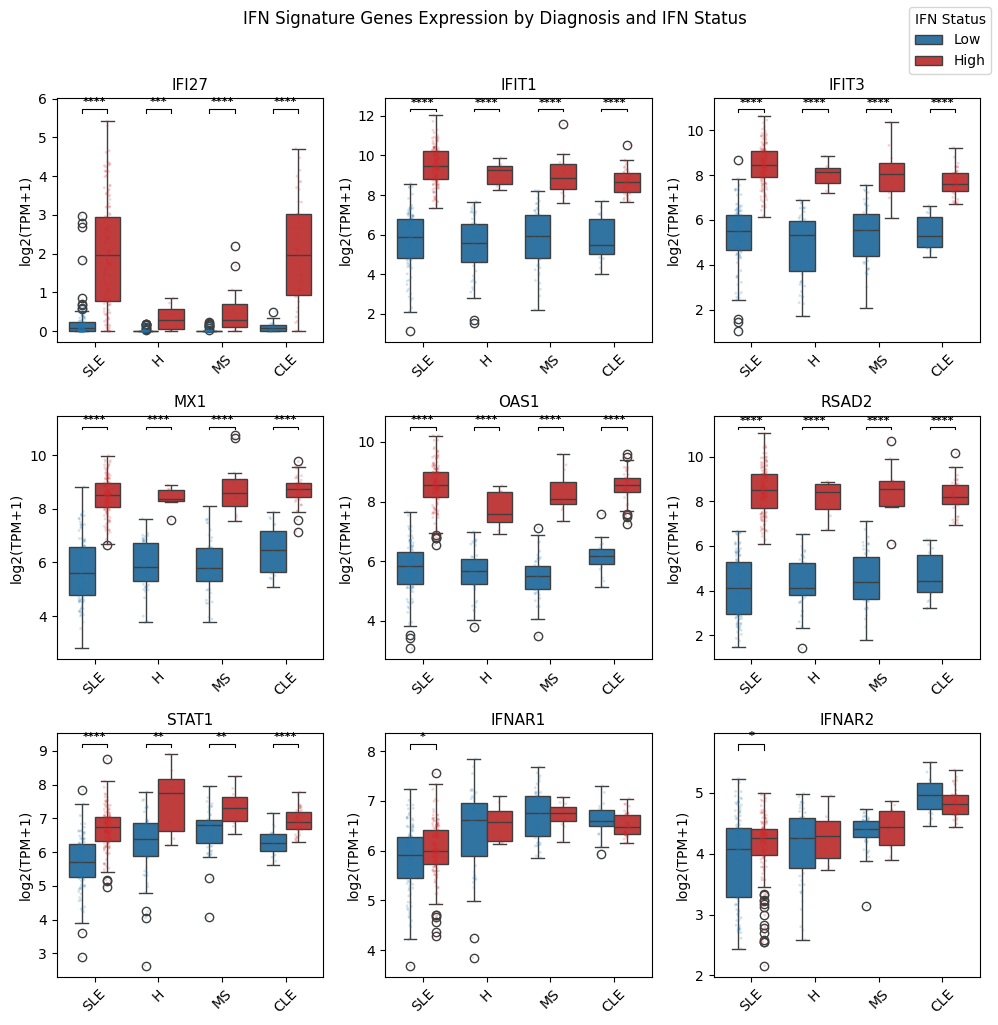

In [13]:
plot_boxplot_stats(log2_tpm, metadata, ifn_genes,
                   condition_col='diagnosis')

As our classifier revealed IFN-high healthy patients, we wondered whether this is a technical mistake or true biologically significant data. We used DESeq2 to analyze differential gene expression between IFN-high and IFN-low healthy patients. We found that IFN-high healthy patients upregulate IFN-inducible antiviral genes, which could indicate that these patients have recently experienced a viral infection, despite being classified as healthy.  
Notably, these patients come from several datasets, which argues against technical batch effect.

In [14]:
healthy_metadata = metadata[metadata['diagnosis'] == 'H'].copy()
healthy_samples = healthy_metadata['SRR'].tolist()
healthy_samples = [s for s in healthy_samples if s in filtered_counts.columns]
counts_for_deseq = filtered_counts[healthy_samples].copy()
counts_for_deseq_T = counts_for_deseq.T.astype(int)
healthy_metadata_deseq = healthy_metadata.set_index('SRR').loc[counts_for_deseq_T.index]
res = run_deseq2(counts_for_deseq_T, healthy_metadata_deseq)

Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.33 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 3.87 seconds.

Fitting LFCs...
... done in 2.58 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 203 outlier genes.

Fitting dispersions...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: Predicted_IFN_status High vs Low
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Geneid                                                                     
A1BG      21.302255        0.092397  0.428185  0.215789  0.829153  0.997310
A1CF       0.682501        0.441282  2.001003  0.220531  0.825458       NaN
A2M      242.632775        1.505690  0.979896  1.536581  0.124396  0.882652
A2ML1      1.837817        1.439391  1.276951  1.127209  0.259654  0.951858
A4GALT    28.800683       -0.229771  1.221532 -0.188101  0.850798  0.997310
...             ...             ...       ...       ...       ...       ...
ZXDC    2398.855582       -0.042998  0.153258 -0.280561  0.779047  0.997310
ZYG11B  2004.398921       -0.358073  0.286917 -1.247999  0.212031  0.929341
ZYX      197.621833       -0.481594  0.565715 -0.851300  0.394603  0.984980
ZZEF1   7931.160532        0.085064  0.174983  0.486128  0.626876  0.997310
ZZZ3    2253.8274

... done in 1.19 seconds.



In [15]:
healthy_metadata[healthy_metadata['Predicted_IFN_status'] == 'High']

,SRR,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,disease_type,country,state_province,continent,ifn_status,Batch,IFN_Probability,Predicted_IFN_status
38,SRR12794715,GSE159225,Leukocytes,H,M,NaN,NaN,total,NaN,H,Spain,NaN,Europe,NaN,2,1.00,High
46,SRR12794723,GSE159225,Leukocytes,H,F,NaN,NaN,total,NaN,H,Spain,NaN,Europe,NaN,2,0.95,High
167,SRR24971714,GSE235357,PBMC,H,NaN,NaN,NaN,polyA,NaN,H,Spain,Madrid,Europe,NaN,0,0.97,High
168,SRR24971716,GSE235357,PBMC,H,NaN,NaN,NaN,polyA,NaN,H,Spain,Madrid,Europe,NaN,0,0.97,High
169,SRR24971718,GSE235357,PBMC,H,NaN,NaN,NaN,polyA,NaN,H,Spain,Madrid,Europe,NaN,0,0.73,High
224,SRR3362737,GSE80183,PBMC,H,F,NaN,IN,polyA,NaN,H,India,Uttar Pradesh,Asia,NaN,0,0.83,High
225,SRR3362738,GSE80183,PBMC,H,F,NaN,IN,polyA,NaN,H,India,Uttar Pradesh,Asia,NaN,1,1.00,High


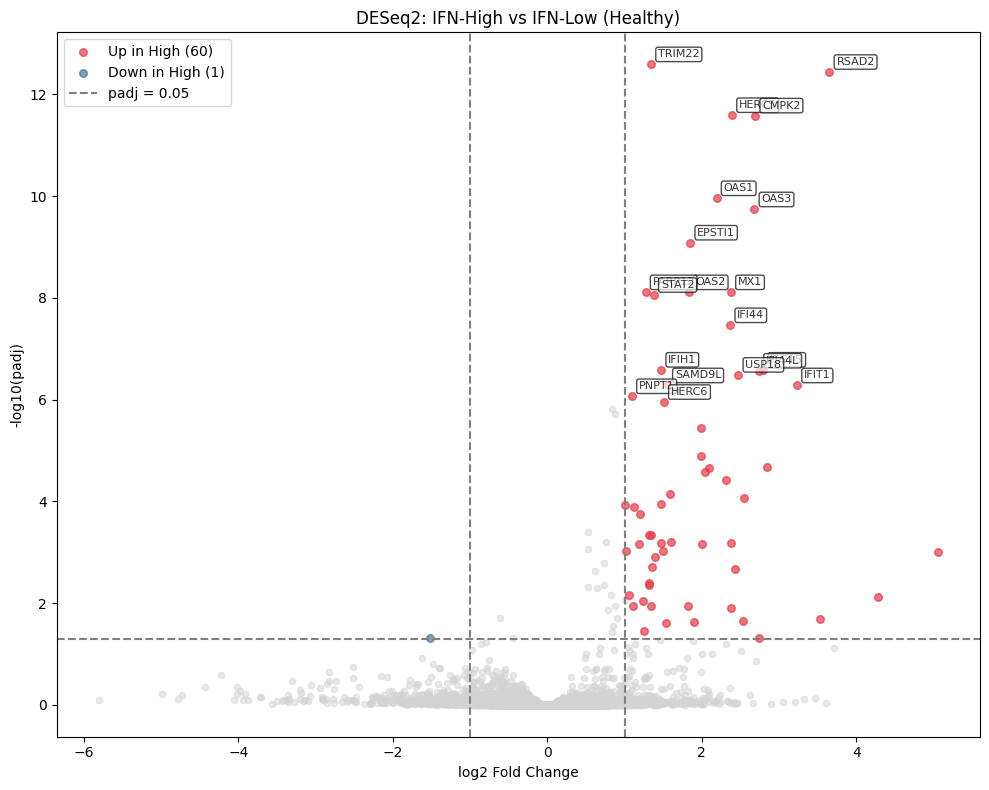

In [16]:
plot_volcano(res, padj_threshold=0.05, lfc_threshold=1)